# Modelos temporais complementares: décadas e splines

Este notebook complementa a regressão linear simples avaliando se a relação entre ano e duração muda quando consideramos contexto histórico por década e possíveis padrões não lineares.

A motivação é que filmes indicados no mesmo período podem compartilhar características industriais, tecnológicas, culturais e regras de premiação. Portanto, além de testar uma reta única, avaliamos:

- médias e inclinações por década;
- modelo com efeitos fixos de década;
- modelo com interação entre década e tendência temporal;
- spline cúbico para permitir curvatura ao longo do tempo.

## 1. Configuração

O notebook usa a camada `gold` e as bibliotecas estatísticas já disponíveis no projeto.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix

In [2]:
sns.set_theme(context="notebook", style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (18, 8)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

In [3]:
def find_project_dir() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "data" / "gold").exists() and candidate.name == "cinematic_chronos":
            return candidate
        nested = candidate / "cinematic_chronos"
        if (nested / "data" / "gold").exists():
            return nested
    raise FileNotFoundError("Não foi possível localizar cinematic_chronos/data/gold.")

In [4]:
PROJECT_DIR = find_project_dir()
GOLD_PATH = PROJECT_DIR / "data" / "gold" / "oscar_best_picture_nominees_runtime.parquet"
ALPHA = 0.05
GOLD_PATH

WindowsPath('c:/WorkspaceHub/SourceHub/data-scientist/cinematic_chronos/data/gold/oscar_best_picture_nominees_runtime.parquet')

## 2. Base analítica

A base mantém uma observação por filme indicado. A década é derivada de `year_film` e representa um agrupamento histórico aproximado.

In [5]:
df = pd.read_parquet(GOLD_PATH)
model_data = df[["film", "year_film", "runtime_minutes", "winner"]].dropna().copy()
model_data["year_film"] = model_data["year_film"].astype(int)
model_data["runtime_minutes"] = model_data["runtime_minutes"].astype(float)
model_data["decade"] = ((model_data["year_film"] // 10) * 10).astype(int)
model_data["year_centered"] = model_data["year_film"] - model_data["year_film"].mean()
model_data["winner_label"] = np.where(model_data["winner"], "Vencedor", "Indicado")

print(f"Observações: {len(model_data):,}")
print(f"Período: {model_data['year_film'].min()}-{model_data['year_film'].max()}")
model_data.head()

Observações: 621
Período: 1927-2025


,film,year_film,runtime_minutes,winner,decade,year_centered,winner_label
0,The Racket,1927,88.0000,False,1920,-50.3591,Indicado
1,7th Heaven,1927,119.0000,False,1920,-50.3591,Indicado
2,Wings,1927,144.0000,True,1920,-50.3591,Vencedor
3,Alibi,1928,90.0000,False,1920,-49.3591,Indicado
4,In Old Arizona,1928,95.0000,False,1920,-49.3591,Indicado


## 3. Perfil por década

Esta etapa resume quantos filmes existem por década e como a duração se distribui em cada período.

In [6]:
decade_summary = (
    model_data.groupby("decade", as_index=False)
    .agg(
        filmes=("film", "count"),
        anos=("year_film", "nunique"),
        runtime_mean=("runtime_minutes", "mean"),
        runtime_median=("runtime_minutes", "median"),
        runtime_std=("runtime_minutes", "std"),
        runtime_min=("runtime_minutes", "min"),
        runtime_max=("runtime_minutes", "max"),
    )
)
decade_summary

,decade,filmes,anos,runtime_mean,runtime_median,runtime_std,runtime_min,runtime_max
0,1920,13,3,107.4615,101.0000,20.0400,88.0000,147.0000
1,1930,87,9,105.4828,102.0000,22.5011,65.0000,233.0000
2,1940,70,10,118.6000,118.0000,20.3102,76.0000,177.0000
3,1950,50,10,128.3800,119.0000,31.3036,85.0000,220.0000
4,1960,50,10,144.3800,138.5000,33.9507,94.0000,251.0000
5,1970,50,10,130.4200,122.0000,28.5901,93.0000,202.0000
6,1980,50,10,127.9600,122.0000,24.4774,92.0000,195.0000
7,1990,50,10,137.4800,135.0000,26.6062,84.0000,195.0000
8,2000,55,10,132.0000,129.0000,24.0670,92.0000,201.0000
9,2010,88,10,126.3182,126.5000,20.6055,89.0000,209.0000


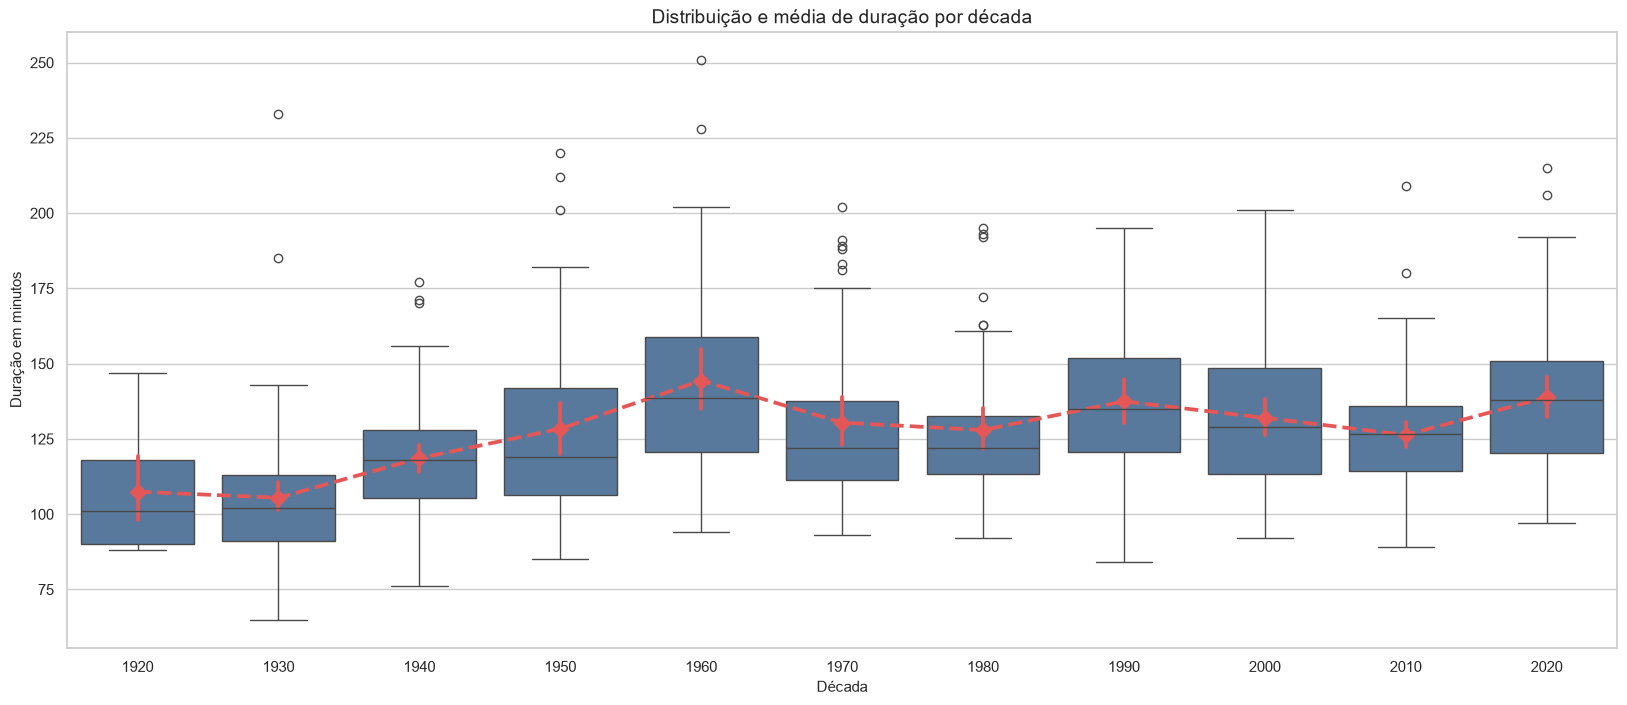

In [7]:
fig, ax = plt.subplots(figsize=(20, 8))
sns.boxplot(data=model_data, x="decade", y="runtime_minutes", color="#4C78A8", ax=ax)
sns.pointplot(
    data=model_data,
    x="decade",
    y="runtime_minutes",
    estimator="mean",
    errorbar=("ci", 95),
    color="#E45756",
    markers="D",
    linestyles="--",
    ax=ax,
)
ax.set_title("Distribuição e média de duração por década")
ax.set_xlabel("Década")
ax.set_ylabel("Duração em minutos")
plt.show()

## 4. Tendência linear dentro de cada década

Aqui estimamos uma regressão linear separada por década. Como algumas décadas têm menos anos observados, os coeficientes devem ser lidos como análise exploratória de heterogeneidade temporal, não como conclusão final isolada.

In [8]:
decade_models = []
for decade, group in model_data.groupby("decade"):
    if group["year_film"].nunique() < 3 or len(group) < 10:
        continue
    X = sm.add_constant(group["year_film"])
    y = group["runtime_minutes"]
    model = sm.OLS(y, X).fit()
    ci_low, ci_high = model.conf_int(alpha=ALPHA).loc["year_film"]
    decade_models.append(
        {
            "decade": decade,
            "filmes": len(group),
            "anos": group["year_film"].nunique(),
            "beta_1_min_por_ano": model.params["year_film"],
            "p_value": model.pvalues["year_film"],
            "ci_low": ci_low,
            "ci_high": ci_high,
            "r_squared": model.rsquared,
        }
    )

decade_model_summary = pd.DataFrame(decade_models)
decade_model_summary

,decade,filmes,anos,beta_1_min_por_ano,p_value,ci_low,ci_high,r_squared
0,1920,13,3,-4.8000,0.5302,-21.1022,11.5022,0.0368
1,1930,87,9,2.7596,0.0013,1.1051,4.4142,0.1146
2,1940,70,10,0.9221,0.2833,-0.7792,2.6235,0.0169
3,1950,50,10,3.6594,0.0160,0.7139,6.6049,0.1150
4,1960,50,10,-3.6255,0.0286,-6.8542,-0.3967,0.0960
5,1970,50,10,-1.6085,0.2574,-4.4298,1.2128,0.0266
6,1980,50,10,-1.7382,0.1511,-4.1339,0.6576,0.0425
7,1990,50,10,-0.2061,0.8769,-2.8666,2.4545,0.0005
8,2000,55,10,-2.2832,0.0317,-4.3593,-0.2072,0.0841
9,2010,88,10,1.3233,0.0787,-0.1548,2.8015,0.0355


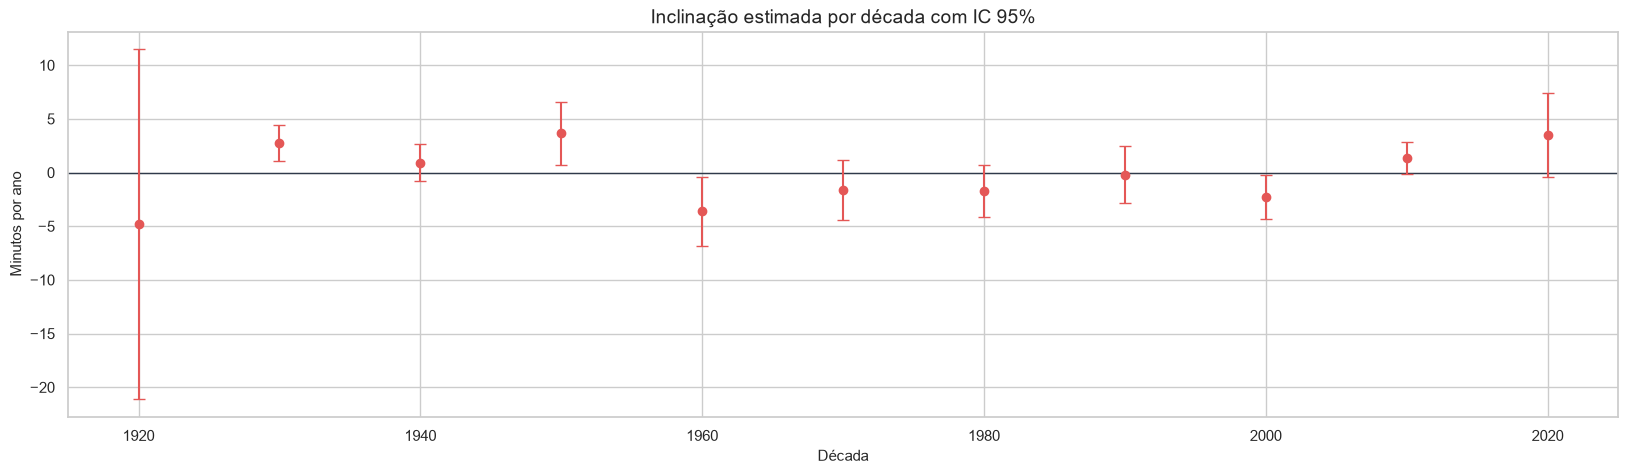

In [9]:
fig, ax = plt.subplots(figsize=(20, 5))
ax.axhline(0, color="#2F3A4A", linewidth=1)
ax.errorbar(
    decade_model_summary["decade"],
    decade_model_summary["beta_1_min_por_ano"],
    yerr=[
        decade_model_summary["beta_1_min_por_ano"] - decade_model_summary["ci_low"],
        decade_model_summary["ci_high"] - decade_model_summary["beta_1_min_por_ano"],
    ],
    fmt="o",
    color="#E45756",
    ecolor="#E45756",
    capsize=4,
)
ax.set_title("Inclinação estimada por década com IC 95%")
ax.set_xlabel("Década")
ax.set_ylabel("Minutos por ano")
plt.show()

## 5. Modelos com década

Comparamos quatro modelos:

- `linear`: tendência única no tempo.
- `decade_fixed`: diferenças médias por década, sem tendência contínua.
- `linear_plus_decade`: tendência contínua controlando diferenças de nível por década.
- `decade_interaction`: inclinação temporal específica por década.

Menor AIC/BIC indica melhor equilíbrio entre ajuste e complexidade dentro da família comparada.

In [10]:
linear = smf.ols("runtime_minutes ~ year_film", data=model_data).fit()
decade_fixed = smf.ols("runtime_minutes ~ C(decade)", data=model_data).fit()
linear_plus_decade = smf.ols("runtime_minutes ~ year_centered + C(decade)", data=model_data).fit()
decade_interaction = smf.ols(
    "runtime_minutes ~ year_centered * C(decade)",
    data=model_data,
).fit()

comparison = pd.DataFrame(
    [
        {
            "modelo": name,
            "n_params": int(model.df_model + 1),
            "r_squared": model.rsquared,
            "adj_r_squared": model.rsquared_adj,
            "aic": model.aic,
            "bic": model.bic,
        }
        for name, model in [
            ("linear", linear),
            ("decade_fixed", decade_fixed),
            ("linear_plus_decade", linear_plus_decade),
            ("decade_interaction", decade_interaction),
        ]
    ]
).sort_values("aic")
comparison

,modelo,n_params,r_squared,adj_r_squared,aic,bic
3,decade_interaction,22,0.2248,0.1976,5765.9963,5863.4856
1,decade_fixed,11,0.1721,0.1585,5784.8640,5833.6086
2,linear_plus_decade,12,0.1727,0.1578,5786.3396,5839.5156
0,linear,2,0.0741,0.0726,5836.2849,5845.1476


In [11]:
anova_comparison = sm.stats.anova_lm(linear, linear_plus_decade, decade_interaction)
anova_comparison

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,619.0000,435921.3843,0.0000,NaN,NaN,NaN
1,609.0000,389486.2329,10.0000,46435.1515,7.6207,0.0000
2,599.0000,364987.6608,10.0000,24498.5721,4.0206,0.0000


## 6. Spline cúbico para tendência não linear

Splines permitem que a curva mude de inclinação ao longo do tempo. A análise abaixo compara a reta simples com um spline cúbico de 5 graus de liberdade.

In [12]:
spline_basis = dmatrix(
    "bs(year_film, df=5, degree=3, include_intercept=False)",
    data=model_data,
    return_type="dataframe",
)
spline_model = sm.OLS(model_data["runtime_minutes"], sm.add_constant(spline_basis)).fit()

spline_comparison = pd.DataFrame(
    [
        {
            "modelo": "linear",
            "n_params": int(linear.df_model + 1),
            "r_squared": linear.rsquared,
            "adj_r_squared": linear.rsquared_adj,
            "aic": linear.aic,
            "bic": linear.bic,
        },
        {
            "modelo": "spline_df5",
            "n_params": int(spline_model.df_model + 1),
            "r_squared": spline_model.rsquared,
            "adj_r_squared": spline_model.rsquared_adj,
            "aic": spline_model.aic,
            "bic": spline_model.bic,
        },
    ]
)
spline_comparison

,modelo,n_params,r_squared,adj_r_squared,aic,bic
0,linear,2,0.0741,0.0726,5836.2849,5845.1476
1,spline_df5,6,0.1620,0.1552,5782.3363,5808.9243


In [13]:
year_grid = pd.DataFrame(
    {"year_film": np.arange(model_data["year_film"].min(), model_data["year_film"].max() + 1)}
)
linear_pred = linear.get_prediction(year_grid).summary_frame(alpha=ALPHA)

spline_grid = dmatrix(
    "bs(year_film, df=5, degree=3, include_intercept=False)",
    data=year_grid,
    return_type="dataframe",
)
spline_pred = spline_model.get_prediction(sm.add_constant(spline_grid)).summary_frame(alpha=ALPHA)

yearly = model_data.groupby("year_film", as_index=False).agg(runtime_mean=("runtime_minutes", "mean"))

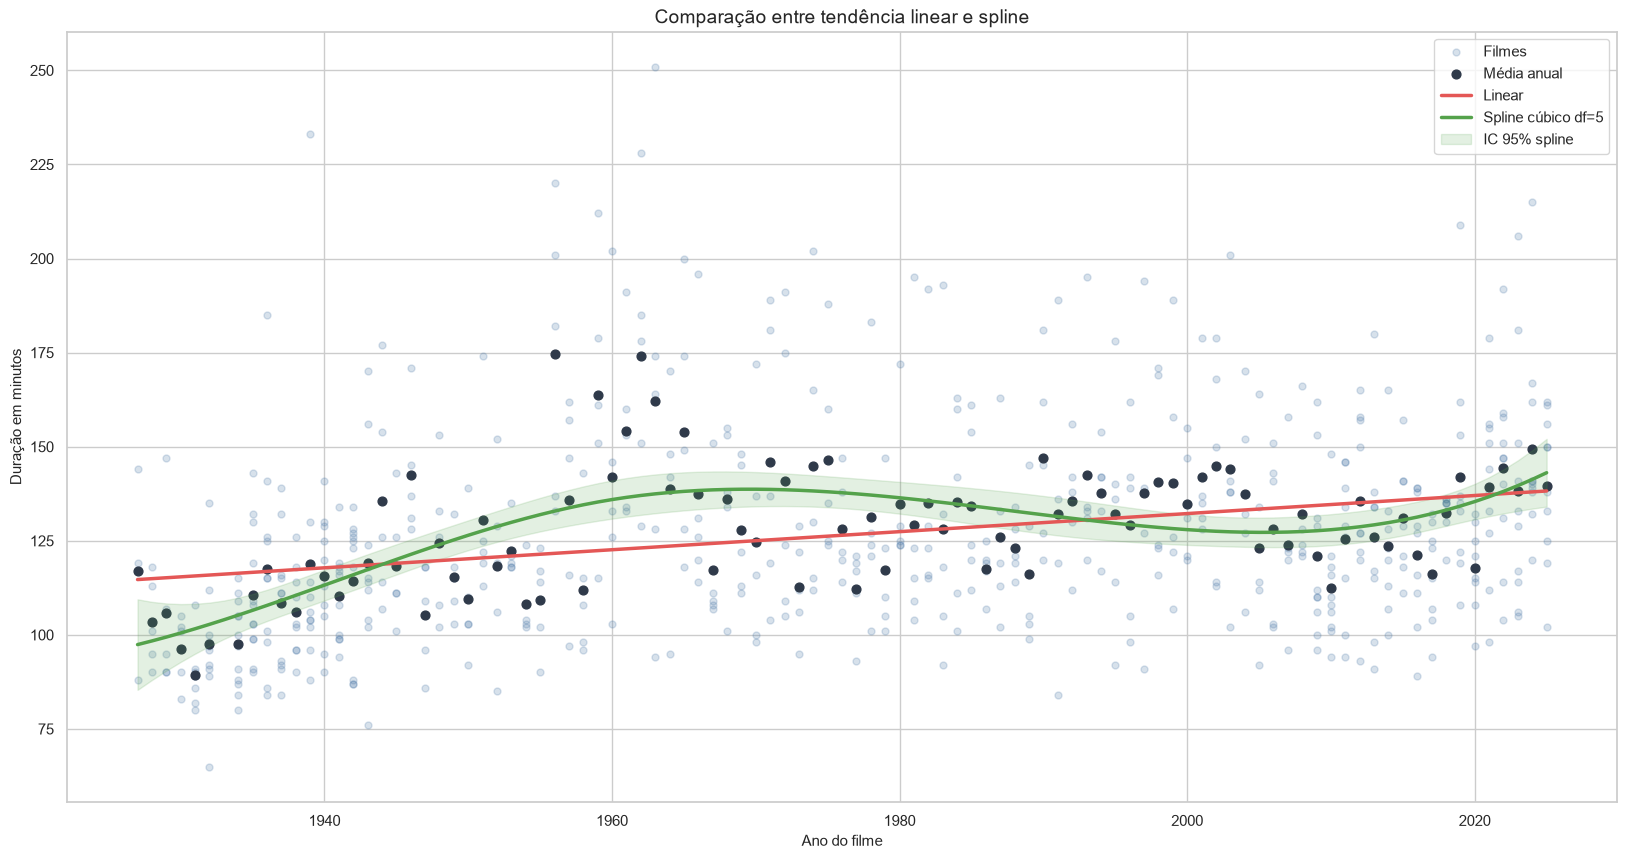

In [14]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.scatter(model_data["year_film"], model_data["runtime_minutes"], alpha=0.22, s=25, color="#4C78A8", label="Filmes")
ax.scatter(yearly["year_film"], yearly["runtime_mean"], color="#2F3A4A", s=40, label="Média anual")
ax.plot(year_grid["year_film"], linear_pred["mean"], color="#E45756", linewidth=2.5, label="Linear")
ax.plot(year_grid["year_film"], spline_pred["mean"], color="#54A24B", linewidth=2.5, label="Spline cúbico df=5")
ax.fill_between(year_grid["year_film"], spline_pred["mean_ci_lower"], spline_pred["mean_ci_upper"], color="#54A24B", alpha=0.16, label="IC 95% spline")
ax.set_title("Comparação entre tendência linear e spline")
ax.set_xlabel("Ano do filme")
ax.set_ylabel("Duração em minutos")
ax.legend()
plt.show()

## 7. Leitura complementar

- Os modelos por década avaliam se a tendência média parece homogênea entre períodos históricos.
- O modelo com efeitos fixos de década testa se há diferenças de nível entre décadas.
- A interação década-tempo permite inclinações diferentes por década, mas aumenta bastante a complexidade.
- O spline mostra se uma curva flexível descreve melhor a tendência do que uma reta única.
- Essas análises não substituem a regressão principal; elas testam a sensibilidade da conclusão a diferentes formas de representar o contexto temporal.